In [1]:
import pandas as pd
import time

In [2]:
train_path = "Data/processed/train_clean.csv"
test_path = "Data/processed/test_clean.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

In [3]:
df_train["text_clean"] = df_train["text_clean"].str.lower()
df_test["text_clean"] = df_test["text_clean"].str.lower()

X_train_text = df_train["text_clean"]
X_test_text = df_test["text_clean"]

y_train = df_train["Class Index"]
y_test = df_test["Class Index"]

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=40000,
    ngram_range=(1,2),
    stop_words="english",
    min_df=5,
    max_df=0.9
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Feature shape:", X_train.shape)

Feature shape: (120000, 40000)


In [5]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


=== Logistic Regression ===
Accuracy: 0.9211842105263158
Classification Report:
               precision    recall  f1-score   support

           1       0.93      0.91      0.92      1900
           2       0.96      0.98      0.97      1900
           3       0.89      0.89      0.89      1900
           4       0.90      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600

Train time: 7.75s
Predict time/sample: 0.000001s


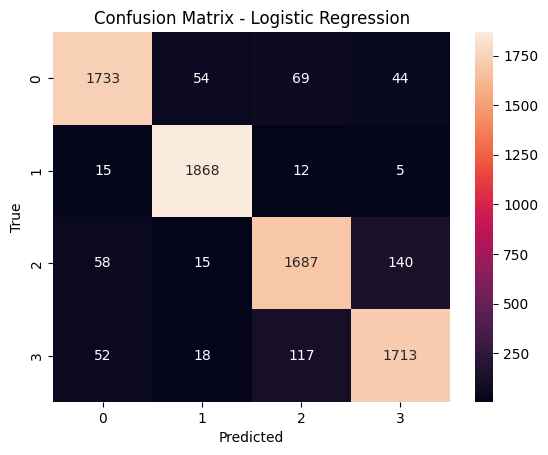

In [6]:
from sklearn.linear_model import LogisticRegression

start = time.time()
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_train_time = time.time() - start

start = time.time()
y_pred_log = log_model.predict(X_test)
log_pred_time = time.time() - start

print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))
print(f"Train time: {log_train_time:.2f}s")
print(f"Predict time/sample: {log_pred_time / X_test.shape[0]:.6f}s")

# Confusion Matrix - Logistic
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure()
sns.heatmap(cm_log, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


=== Linear SVM ===
Accuracy: 0.9246052631578947
Classification Report:
               precision    recall  f1-score   support

           1       0.94      0.92      0.93      1900
           2       0.96      0.98      0.97      1900
           3       0.90      0.89      0.90      1900
           4       0.90      0.91      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600

Train time: 6.56s
Predict time/sample: 0.000000s


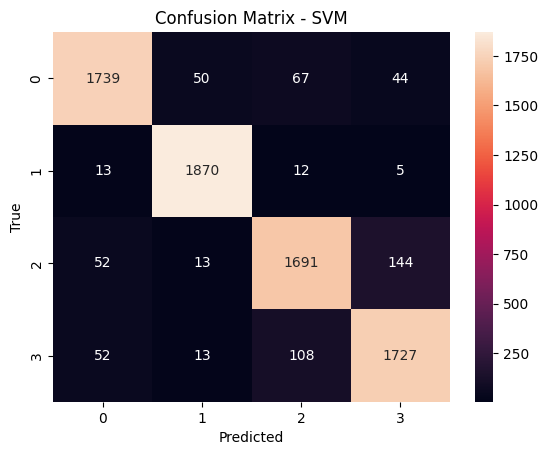

In [7]:
from sklearn.svm import LinearSVC

start = time.time()
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
svm_train_time = time.time() - start

start = time.time()
y_pred_svm = svm_model.predict(X_test)
svm_pred_time = time.time() - start

print("\n=== Linear SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))
print(f"Train time: {svm_train_time:.2f}s")
print(f"Predict time/sample: {svm_pred_time / X_test.shape[0]:.6f}s")

# Confusion Matrix - SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure()
sns.heatmap(cm_svm, annot=True, fmt="d")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [8]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Train Time (s)": [log_train_time, svm_train_time],
    "Predict Time/sample (s)": [
        log_pred_time / X_test.shape[0],
        svm_pred_time / X_test.shape[0]
    ]
})

print("\n=== Model Comparison ===")
print(results)


=== Model Comparison ===
                 Model  Accuracy  Train Time (s)  Predict Time/sample (s)
0  Logistic Regression  0.921184        7.746481             6.589137e-07
1                  SVM  0.924605        6.564847             3.947710e-07


In [9]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

for i, class_label in enumerate(log_model.classes_):
    top10 = np.argsort(log_model.coef_[i])[-10:]
    print(f"\nTop words for class {class_label}:")
    print([feature_names[j] for j in top10])


Top words for class 1:
['york stocks', 'afp afp', 'palestinian', 'athens greece', 'president', 'nuclear', 'canadian press', 'iraqi', 'afp', 'iraq']

Top words for class 2:
['players', 'baseball', 'olympic', 'stadium', 'season', 'sports', 'league', 'team', 'cup', 'coach']

Top words for class 3:
['business', 'airlines', 'corp', 'tax', 'company', 'economic', 'bank', 'hellip', 'economy', 'oil']

Top words for class 4:
['linux', 'technology', 'apple', 'web', 'microsoft', 'scientists', 'software', 'space', 'nasa', 'internet']


In [10]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

for i, class_label in enumerate(svm_model.classes_):
    top10 = np.argsort(svm_model.coef_[i])[-10:]
    
    print(f"\nTop words for class {class_label} (SVM):")
    print([feature_names[j] for j in top10])


Top words for class 1 (SVM):
['ap ap', 'palestinian', 'arafat', 'ap president', 'iraq', 'ap tokyo', 'afp afp', 'york stocks', 'athens greece', 'canadian press']

Top words for class 2 (SVM):
['nhl', 'players', 'team', 'league', 'cup', 'stadium', 'nba', 'nascar', 'coach', 'sports']

Top words for class 3 (SVM):
['oracle 39', 'martha', 'enron', 'retailers', 'halliburton', 'economy', 'airplanes', 'investing', 'adv', 'hellip']

Top words for class 4 (SVM):
['xbox', 'reuters reuters', 'space', 'hp', 'linux', 'wired magazine', 'internet', 'ap', 'washington ap', 'nasa']


In [11]:
mis_idx_log = (y_test != y_pred_log)

print("\n=== Misclassified - Logistic Regression ===")

for i in df_test[mis_idx_log].index[:5]:
    print("\nText:", X_test_text.iloc[i])
    print("True:", y_test.iloc[i], "Pred:", y_pred_log[i])

mis_idx_svm = (y_test != y_pred_svm)

print("\n=== Misclassified - SVM ===")

for i in df_test[mis_idx_svm].index[:5]:
    print("\nText:", X_test_text.iloc[i])
    print("True:", y_test.iloc[i], "Pred:", y_pred_svm[i])


=== Misclassified - Logistic Regression ===

Text: ibm to hire even more new workers by the end of the year, the computing giant plans to have its biggest headcount since 1991.
True: 4 Pred: 3

Text: some people not eligible to get in on google ipo google has billed its ipo as a way for everyday people to get in on the process, denying wall street the usual stranglehold it's had on ipos. public bidding, a minimum of just five shares, an open process with 28 underwriters - all this pointed to a new level of public participation. but this isn't the case.
True: 4 Pred: 3

Text: rivals try to turn tables on charles schwab by michael liedtke san francisco (ap) -- with its low prices and iconoclastic attitude, discount stock broker charles schwab corp. (sch) represented an annoying stone in wall street's wing-tipped shoes for decades...
True: 4 Pred: 3

Text: venezuela prepares for chavez recall vote supporters and rivals warn of possible fraud; government says chavez's defeat could produce

In [12]:
from sklearn.metrics import confusion_matrix
import numpy as np

def print_class_accuracy(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    
    print(f"\n=== {model_name} - Class-wise Accuracy ===")
    for i, acc in enumerate(class_acc):
        print(f"Class {i+1}: {acc:.4f}")

# Logistic
print_class_accuracy(y_test, y_pred_log, "Logistic Regression")

# SVM
print_class_accuracy(y_test, y_pred_svm, "SVM")


=== Logistic Regression - Class-wise Accuracy ===
Class 1: 0.9121
Class 2: 0.9832
Class 3: 0.8879
Class 4: 0.9016

=== SVM - Class-wise Accuracy ===
Class 1: 0.9153
Class 2: 0.9842
Class 3: 0.8900
Class 4: 0.9089


In [13]:
import numpy as np

importance = np.abs(svm_model.coef_).mean(axis=0)

top_global = np.argsort(importance)[-10:]

print("Global important words:")
print([feature_names[i] for i in top_global])

Global important words:
['afp', 'york stocks', 'athens greece', 'internet', 'nasa', 'ap ap', 'ap', 'hellip', 'afp afp', 'canadian press']
